In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr, spearmanr
from adjustText import adjust_text
from Bio.Data import CodonTable
from collections import defaultdict

In [2]:
aa_column_mapping = {
    "Phe": "F",
    "Leu": "L",
    "Leu2": "L",
    "Ile": "I",
    "Met": "M",
    "Val": "V",
    "Ser": "S",
    "Ser2": "S",
    "Pro": "P",
    "Thr": "T",
    "Ala": "A",
    "Tyr": "Y",
    "His": "H",
    "Gln": "Q",
    "Asn": "N",
    "Lys": "K",
    "Asp": "D",
    "Glu": "E",
    "Cys": "C",
    "Trp": "W",
    "Arg": "R",
    "Gly": "G"
}

aa_names = {
    "A": "Ala",
    "R": "Arg",
    "N": "Asn",
    "D": "Asp",
    "C": "Cys",
    "Q": "Gln",
    "E": "Glu",
    "G": "Gly",
    "H": "His",
    "I": "Ile",
    "L": "Leu",
    "K": "Lys",
    "M": "Met",
    "F": "Phe",
    "P": "Pro",
    "S": "Ser",
    "T": "Thr",
    "W": "Trp",
    "Y": "Tyr",
    "V": "Val"
}

In [3]:
mt_table = CodonTable.unambiguous_dna_by_id[2]

heavy_genes = ["ND1", "ND4", "ND4L", "ND5"]

light_genes = [
    "A6", "A8", "CO1", "CO2", "CO3",
    "Cytb", "ND2", "ND3", "ND6"
]

In [4]:
mutspec_ter = pd.read_csv('../data/termite_mutspec12.csv', index_col=0)

mutspec_coc = pd.read_csv('../data/cocroach_mutspec12.csv', index_col=0)

In [5]:
blat_aa = pd.read_csv('../data/midori_Blattodea_aa_fracs.tsv', sep='\t')

In [6]:
blat_aa

,Species_name,Organism,Gene_name,Phe_frac,Leu_frac,Leu2_frac,Ser_frac,Pro_frac,Cys_frac,Trp_frac,...,Ser2_frac,Asp_frac,Glu_frac,Asn_frac,Lys_frac,Val_frac,Ile_frac,Met_frac,Ala_frac,Thr_frac
0,Acanthotermes_acanthothorax_187525,Termites,A6,0.052863,0.017621,0.004405,0.088106,0.008811,0.083700,0.066079,...,0.008811,0.088106,0.061674,0.017621,0.030837,0.101322,0.008811,0.013216,0.022026,0.004405
1,Acanthotermes_acanthothorax_187525,Termites,A8,0.094340,0.056604,0.037736,0.056604,0.000000,0.094340,0.018868,...,0.037736,0.037736,0.075472,0.018868,0.018868,0.113208,0.056604,0.000000,0.018868,0.000000
2,Acanthotermes_acanthothorax_187525,Termites,CO1,0.029183,0.017510,0.007782,0.145914,0.003891,0.089494,0.068093,...,0.023346,0.048638,0.075875,0.036965,0.033074,0.105058,0.011673,0.009728,0.009728,0.007782
3,Acanthotermes_acanthothorax_187525,Termites,CO2,0.047619,0.051948,0.012987,0.090909,0.008658,0.082251,0.073593,...,0.012987,0.056277,0.043290,0.043290,0.004329,0.121212,0.021645,0.017316,0.034632,0.008658
4,Acanthotermes_acanthothorax_187525,Termites,CO3,0.045627,0.034221,0.003802,0.136882,0.007605,0.121673,0.068441,...,0.019011,0.049430,0.079848,0.034221,0.026616,0.106464,0.011407,0.015209,0.011407,0.011407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5156,Zootermopsis_nevadensis_136037,Termites,ND3,0.076271,0.016949,0.016949,0.093220,0.016949,0.127119,0.059322,...,0.008475,0.067797,0.033898,0.050847,0.050847,0.050847,0.008475,0.008475,0.008475,0.000000
5157,Zootermopsis_nevadensis_136037,Termites,ND4,0.006726,0.002242,0.026906,0.022422,0.047085,0.004484,0.015695,...,0.123318,0.008969,0.006726,0.121076,0.141256,0.004484,0.040359,0.060538,0.002242,0.130045
5158,Zootermopsis_nevadensis_136037,Termites,ND4L,0.000000,0.020833,0.041667,0.010417,0.031250,0.000000,0.010417,...,0.072917,0.000000,0.000000,0.125000,0.177083,0.000000,0.041667,0.104167,0.000000,0.135417
5159,Zootermopsis_nevadensis_136037,Termites,ND5,0.006957,0.005217,0.027826,0.027826,0.038261,0.001739,0.005217,...,0.146087,0.001739,0.008696,0.137391,0.165217,0.001739,0.059130,0.055652,0.003478,0.104348


In [7]:
COMPLEMENT = {
    "A": "T",
    "T": "A",
    "C": "G",
    "G": "C"
}


def reverse_mutspec(mutspec_df):
    df = mutspec_df.copy()

    df["Mut"] = (
        df["Mut"]
        .str.split(">")
        .apply(lambda x: f"{COMPLEMENT[x[0]]}>{COMPLEMENT[x[1]]}")
    )

    return df

In [8]:
def average_mutspec(mutspec_df):

    return (
        mutspec_df
        .groupby("Mut", as_index=False)["MutSpec"]
        .mean()
    )

In [9]:
def predict_amino_acid_composition(mutspec):

    mut_dict = dict(zip(mutspec["Mut"], mutspec["MutSpec"]))

    coding_codons = mt_table.forward_table

    codon_weight = 1 / len(coding_codons)

    #########################################
    # Initial amino acid composition
    #########################################

    aa_comp = defaultdict(float)

    for aa in coding_codons.values():
        aa_comp[aa] += codon_weight

    #########################################
    # Apply one random mutation
    #########################################

    for codon, aa_from in coding_codons.items():

        possible = []

        for pos in range(3):

            ref = codon[pos]

            for alt in "ACGT":

                if alt == ref:
                    continue

                mut = f"{ref}>{alt}"

                if mut not in mut_dict:
                    continue

                new_codon = (
                    codon[:pos] +
                    alt +
                    codon[pos+1:]
                )

                if new_codon in mt_table.stop_codons:
                    continue

                aa_to = coding_codons[new_codon]

                possible.append(
                    (
                        aa_to,
                        mut_dict[mut]
                    )
                )

        if len(possible) == 0:
            continue

        total_prob = sum(x[1] for x in possible)

        if total_prob == 0:
            continue

        for aa_to, prob in possible:

            contribution = (
                codon_weight *
                prob /
                total_prob
            )

            aa_comp[aa_from] -= contribution
            aa_comp[aa_to] += contribution

    predicted = pd.DataFrame({
        "amino_acid": list(aa_comp.keys()),
        "predicted": list(aa_comp.values())
    })

    predicted["amino_acid"] = (
        predicted["amino_acid"]
        .map(aa_names)
    )

    predicted["predicted"] /= predicted["predicted"].sum()

    predicted = predicted.sort_values("amino_acid")

    return predicted

In [10]:
def observed_amino_acids(blat_aa, genes):

    df = blat_aa.loc[
        blat_aa["Gene_name"].isin(genes)
    ]
    
    df["Leu_frac"] = (
        df["Leu_frac"]
        + df["Leu2_frac"]
    )

    # Merge Ser + Ser2
    df["Ser_frac"] = (
        df["Ser_frac"]
        + df["Ser2_frac"]
    )

    # Remove auxiliary columns
    df = df.drop(
        columns=[
            "Leu2_frac",
            "Ser2_frac"
        ]
    )
    
    aa_cols = [c for c in df.columns if c.endswith("_frac")]

    termites = (
        df.loc[df["Organism"] == "Termites", aa_cols]
        .mean()
        .rename("mean_termites")
    )

    cockroaches = (
        df.loc[df["Organism"] == "Cockroaches", aa_cols]
        .mean()
        .rename("mean_cockroaches")
    )

    observed = pd.concat(
        [termites, cockroaches],
        axis=1
    ).reset_index()

    observed = observed.rename(
        columns={"index": "aa"}
    )

    observed["amino_acid"] = (
        observed["aa"]
        .str.replace("_frac", "", regex=False)
    )

    observed["observed_delta"] = (
        observed["mean_termites"]
        -
        observed["mean_cockroaches"]
    )

    observed["observed_change"] = np.where(
        observed["observed_delta"] > 0,
        "Termites have more",
        "Cocroaches have more"
    )
    
    observed["amino_acid"] = (
        observed["amino_acid"]
            .map(aa_column_mapping)   # Phe -> F
            .map(aa_names)            # F -> Phe
    )

    return observed[
        [
            "amino_acid",
            "mean_termites",
            "mean_cockroaches",
            "observed_delta",
            "observed_change"
        ]
    ]

In [11]:
def make_aa_summary(
    blat_aa,
    mutspec_ter,
    mutspec_coc,
    genes,
    reverse=False
):

    ter = average_mutspec(mutspec_ter)
    coc = average_mutspec(mutspec_coc)

    if reverse:
        ter = reverse_mutspec(ter)
        coc = reverse_mutspec(coc)

    ##################################
    # Predicted compositions
    ##################################

    pred_ter = (
        predict_amino_acid_composition(ter)
        .rename(columns={"predicted": "predicted_termites"})
    )

    pred_coc = (
        predict_amino_acid_composition(coc)
        .rename(columns={"predicted": "predicted_cockroaches"})
    )

    predicted = pred_ter.merge(
        pred_coc,
        on="amino_acid"
    )

    predicted["predicted_delta"] = (
        predicted["predicted_termites"]
        -
        predicted["predicted_cockroaches"]
    )

    predicted["mutation_predicted_change"] = np.where(
        predicted["predicted_delta"] > 0,
        "Termites have more",
        "Cocroaches have more"
    )

    ##################################
    # Observed compositions
    ##################################

    observed = observed_amino_acids(
        blat_aa,
        genes
    )

    ##################################
    # Merge
    ##################################

    summary = observed.merge(
        predicted,
        on="amino_acid"
    )

    summary["direction_match"] = (
        np.sign(summary["observed_delta"])
        ==
        np.sign(summary["predicted_delta"])
    )

    return summary.sort_values(
        "observed_delta"
    ).reset_index(drop=True)

In [12]:
heavy_genes = [
    "ND1",
    "ND4",
    "ND4L",
    "ND5"
]

light_genes = [
    "A6",
    "A8",
    "CO1",
    "CO2",
    "CO3",
    "Cytb",
    "ND2",
    "ND3",
    "ND6"
]

light_aa_summary = make_aa_summary(
    blat_aa,
    mutspec_ter,
    mutspec_coc,
    genes=light_genes,
    reverse=False
)

heavy_aa_summary = make_aa_summary(
    blat_aa,
    mutspec_ter,
    mutspec_coc,
    genes=heavy_genes,
    reverse=True
)

C:\Users\voron\AppData\Local\Temp\ipykernel_3000\4099679824.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Leu_frac"] = (
C:\Users\voron\AppData\Local\Temp\ipykernel_3000\4099679824.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Ser_frac"] = (
C:\Users\voron\AppData\Local\Temp\ipykernel_3000\4099679824.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

In [13]:
light_aa_summary

,amino_acid,mean_termites,mean_cockroaches,observed_delta,observed_change,predicted_termites,predicted_cockroaches,predicted_delta,mutation_predicted_change,direction_match
0,Asn,0.047155,0.103111,-0.055956,Cocroaches have more,0.034353,0.053008,-0.018654,Cocroaches have more,True
1,Lys,0.030448,0.067728,-0.037280,Cocroaches have more,0.024909,0.049371,-0.024462,Cocroaches have more,True
2,Ile,0.027811,0.056364,-0.028553,Cocroaches have more,0.049932,0.052042,-0.002110,Cocroaches have more,True
3,Met,0.017287,0.041988,-0.024702,Cocroaches have more,0.039644,0.057598,-0.017954,Cocroaches have more,True
4,Ser,0.125861,0.145462,-0.019601,Cocroaches have more,0.097782,0.088733,0.009049,Termites have more,False
5,Thr,0.010142,0.023234,-0.013092,Cocroaches have more,0.042982,0.050948,-0.007966,Cocroaches have more,True
6,Phe,0.055509,0.057065,-0.001556,Cocroaches have more,0.074524,0.054160,0.020364,Termites have more,False
7,Trp,0.063387,0.060846,0.002541,Termites have more,0.033162,0.039401,-0.006239,Cocroaches have more,False
8,Tyr,0.113882,0.109452,0.004429,Termites have more,0.044306,0.050611,-0.006304,Cocroaches have more,False
9,Gln,0.009214,0.004089,0.005125,Termites have more,0.020511,0.027210,-0.006699,Cocroaches have more,False


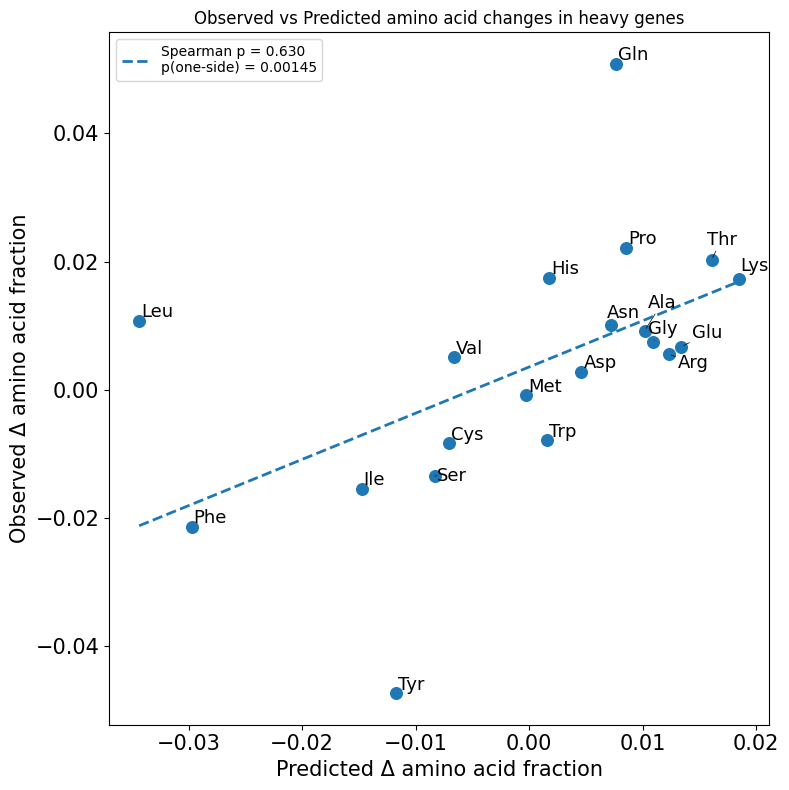

Spearman rho = 0.6301
One-side p-value = 0.001452


In [14]:
# Данные
x = heavy_aa_summary["predicted_delta"]
y = heavy_aa_summary["observed_delta"]

# Линейная регрессия
rho, p = spearmanr(x, y, alternative="greater")

# Линия регрессии
#x_line = sorted(x)
#y_line = [slope * xi + intercept for xi in x_line]

# График
plt.figure(figsize=(8, 8))

plt.scatter(x, y, s=70)

coef = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)

plt.plot(x_line, coef[0] * x_line + coef[1],
         linestyle='--',
         linewidth=2,
         label=f"Spearman p = {rho:.3f}\np(one-side) = {p:.3g}")

# Подписи аминокислот
texts = []
for _, row in heavy_aa_summary.iterrows():
    texts.append(
    plt.text(row["predicted_delta"],
             row["observed_delta"],
             row["amino_acid"],
             fontsize=13))
adjust_text(texts, arrowprops=dict(arrowstyle = "-", lw=0.5))

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel("Predicted Δ amino acid fraction",fontsize=15)
plt.ylabel("Observed Δ amino acid fraction",fontsize=15)
plt.title("Observed vs Predicted amino acid changes in heavy genes")
plt.legend()
plt.tight_layout()

plt.savefig('../figures/aa_changes_corr_heavy_spermn.pdf', dpi=300, bbox_inches = 'tight')
plt.show()

print(f"Spearman rho = {rho:.4f}")
print(f"One-side p-value = {p:.4g}")

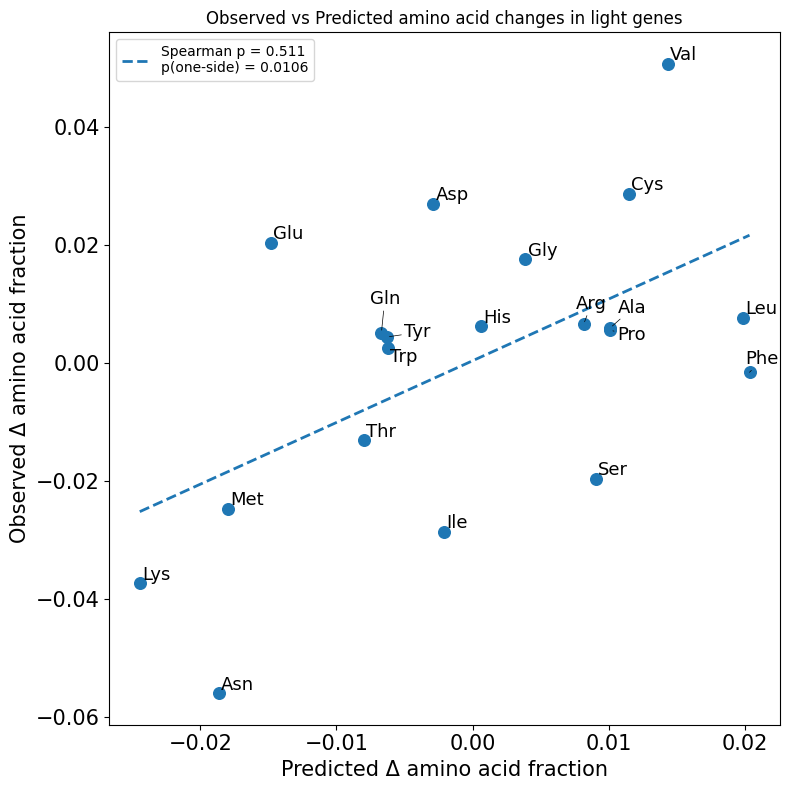

Spearman rho = 0.5113
One-side p-value = 0.01061


In [15]:
# Данные
x = light_aa_summary["predicted_delta"]
y = light_aa_summary["observed_delta"]

# Линейная регрессия
rho, p = spearmanr(x, y, alternative="greater")

# Линия регрессии
#x_line = sorted(x)
#y_line = [slope * xi + intercept for xi in x_line]

# График
plt.figure(figsize=(8, 8))

plt.scatter(x, y, s=70)

coef = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)

plt.plot(x_line, coef[0] * x_line + coef[1],
         linestyle='--',
         linewidth=2,
         label=f"Spearman p = {rho:.3f}\np(one-side) = {p:.3g}")

# Подписи аминокислот
texts = []
for _, row in light_aa_summary.iterrows():
    texts.append(
    plt.text(row["predicted_delta"],
             row["observed_delta"],
             row["amino_acid"],
             fontsize=13))
adjust_text(texts, arrowprops=dict(arrowstyle = "-", lw=0.5))

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel("Predicted Δ amino acid fraction",fontsize=15)
plt.ylabel("Observed Δ amino acid fraction",fontsize=15)
plt.title("Observed vs Predicted amino acid changes in light genes")
plt.legend()
plt.tight_layout()

plt.savefig('../figures/aa_changes_corr_light_spermn.pdf', dpi=300, bbox_inches = 'tight')
plt.show()

print(f"Spearman rho = {rho:.4f}")
print(f"One-side p-value = {p:.4g}")

In [16]:
def summarize_mutational_agreement(comparison):
    
    comparison = comparison.copy()
    comparison['abs_delta'] = comparison['observed_delta'].abs()
    
    total = comparison['abs_delta'].sum()
    
    matched = comparison.loc[comparison["direction_match"], "abs_delta"].sum()
    unmatched = comparison.loc[~comparison["direction_match"], "abs_delta"].sum()
    
    n_match = comparison["direction_match"].sum()
    n_unmatch = (~comparison["direction_match"]).sum()
    
    return pd.Series({"Matched_AA" : n_match,
                     "Unmatched_AA" : n_unmatch,
                     "Matched_%AA" : 100 * n_match / len(comparison),
                     "Matched_%Change" : 100 * matched / total,
                     "Unmatched_%Change" : 100 * unmatched / total})

In [17]:
light_summary = summarize_mutational_agreement(light_aa_summary)
heavy_summary = summarize_mutational_agreement(heavy_aa_summary)

summary = pd.DataFrame({"Light genes" : light_summary,
                       "Heavy_genes" : heavy_summary}).T

summary

,Matched_AA,Unmatched_AA,Matched_%AA,Matched_%Change,Unmatched_%Change
Light genes,13.0,7.0,65.0,78.144185,21.855815
Heavy_genes,17.0,3.0,85.0,92.083586,7.916414


In [18]:
def summarize_divergence(comparison):
    df = comparison.copy()
    
    df['abs_observed'] = df['observed_delta'].abs()
    
    df['consistent'] = (df['observed_delta'] * df['predicted_delta'] > 0)
    
    total_divergence = df['abs_observed'].sum()
    
    consistent_divergence = df.loc[df['consistent'], 'abs_observed'].sum()
    inconsistent_divergence = df.loc[~df['consistent'], 'abs_observed'].sum()
    
    return pd.Series({
        "Total divergence" : total_divergence,
        "Spectrum-consistent divergence" : consistent_divergence,
        "Spectrum-inconsistent divergence" : inconsistent_divergence,
        "Consistent (%)" : 100 * consistent_divergence / total_divergence,
        "Inconsistent (%)" : 100 * inconsistent_divergence / total_divergence
    })

In [19]:
light_summary_divergence = summarize_divergence(light_aa_summary)
heavy_summary_divergence = summarize_divergence(heavy_aa_summary)

summary_divergence = pd.DataFrame({"Light genes" : light_summary_divergence,
                       "Heavy_genes" : heavy_summary_divergence}).T

summary_divergence.round(3)

,Total divergence,Spectrum-consistent divergence,Spectrum-inconsistent divergence,Consistent (%),Inconsistent (%)
Light genes,0.369,0.289,0.081,78.144,21.856
Heavy_genes,0.300,0.277,0.024,92.084,7.916


In [21]:
light_aa_summary

,amino_acid,mean_termites,mean_cockroaches,observed_delta,observed_change,predicted_termites,predicted_cockroaches,predicted_delta,mutation_predicted_change,direction_match
0,Asn,0.047155,0.103111,-0.055956,Cocroaches have more,0.034353,0.053008,-0.018654,Cocroaches have more,True
1,Lys,0.030448,0.067728,-0.037280,Cocroaches have more,0.024909,0.049371,-0.024462,Cocroaches have more,True
2,Ile,0.027811,0.056364,-0.028553,Cocroaches have more,0.049932,0.052042,-0.002110,Cocroaches have more,True
3,Met,0.017287,0.041988,-0.024702,Cocroaches have more,0.039644,0.057598,-0.017954,Cocroaches have more,True
4,Ser,0.125861,0.145462,-0.019601,Cocroaches have more,0.097782,0.088733,0.009049,Termites have more,False
5,Thr,0.010142,0.023234,-0.013092,Cocroaches have more,0.042982,0.050948,-0.007966,Cocroaches have more,True
6,Phe,0.055509,0.057065,-0.001556,Cocroaches have more,0.074524,0.054160,0.020364,Termites have more,False
7,Trp,0.063387,0.060846,0.002541,Termites have more,0.033162,0.039401,-0.006239,Cocroaches have more,False
8,Tyr,0.113882,0.109452,0.004429,Termites have more,0.044306,0.050611,-0.006304,Cocroaches have more,False
9,Gln,0.009214,0.004089,0.005125,Termites have more,0.020511,0.027210,-0.006699,Cocroaches have more,False


In [26]:
def calculate_consistent_stats(df):
    """
    Calculate total, consistent and inconsistent divergence.
    """

    df = df.copy()

    # Consistency of direction
    df["direction_match"] = (
        df["observed_delta"] * df["predicted_delta"] > 0
    )

    # Total divergence
    total_divergence = df["observed_delta"].abs().sum()

    # Divergence consistent with mutational spectrum
    consistent_divergence = (
        df.loc[df["direction_match"], "observed_delta"]
        .abs()
        .sum()
    )

    # Divergence inconsistent with mutational spectrum
    inconsistent_divergence = (
        df.loc[~df["direction_match"], "observed_delta"]
        .abs()
        .sum()
    )

    consistent_percent = (
        100 * consistent_divergence / total_divergence
    )

    return {
        "total_divergence": total_divergence,
        "consistent_divergence": consistent_divergence,
        "inconsistent_divergence": inconsistent_divergence,
        "consistent_percent": consistent_percent
    }


def plot_observed_vs_predicted(
    df,
    strand_name,
    ax=None
):

    df = df.copy()

    # Remove missing values
    df = df.dropna(
        subset=["observed_delta", "predicted_delta"]
    )

    # Direction agreement
    df["direction_match"] = (
        df["observed_delta"] * df["predicted_delta"] > 0
    )

    # Statistics
    stats = calculate_consistent_stats(df)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # --------------------------------------------------
    # Point size
    # --------------------------------------------------

    # Avoid zero-size points
    min_size = 40
    max_size = 500

    abs_delta = df["observed_delta"].abs()

    if abs_delta.max() > 0:
        sizes = (
            min_size
            + (abs_delta / abs_delta.max())
            * (max_size - min_size)
        )
    else:
        sizes = np.full(len(df), min_size)

    # --------------------------------------------------
    # Plot points
    # --------------------------------------------------

    for consistent_value, group in df.groupby("direction_match"):

        idx = group.index

        ax.scatter(
            group["observed_delta"],
            group["predicted_delta"],
            s=sizes[df.index.get_indexer(idx)],
            alpha=0.75,
            edgecolor="black",
            linewidth=0.7,
            label=(
                "Consistent"
                if consistent_value
                else "Inconsistent"
            )
        )

    # --------------------------------------------------
    # Zero lines
    # --------------------------------------------------

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1,
        alpha=0.6
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1,
        alpha=0.6
    )

    # --------------------------------------------------
    # y = x
    # --------------------------------------------------

    min_value = min(
        df["observed_delta"].min(),
        df["predicted_delta"].min()
    )

    max_value = max(
        df["observed_delta"].max(),
        df["predicted_delta"].max()
    )

    margin = 0.08 * (max_value - min_value)

    lower = min_value - margin
    upper = max_value + margin

    ax.plot(
        [lower, upper],
        [lower, upper],
        linestyle=":",
        linewidth=1.5,
        alpha=0.8,
        label="Observed = Predicted"
    )

    # --------------------------------------------------
    # Amino acid labels
    # --------------------------------------------------

    for _, row in df.iterrows():

        aa = row["amino_acid"]

        ax.annotate(
            aa,
            (
                row["observed_delta"],
                row["predicted_delta"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=10
        )

    # --------------------------------------------------
    # Labels
    # --------------------------------------------------

    ax.set_xlabel(
        r"Observed difference ($\Delta p_{observed}$)",
        fontsize=12
    )

    ax.set_ylabel(
        r"Predicted difference ($\Delta p_{predicted}$)",
        fontsize=12
    )

    ax.set_title(
        f"{strand_name} strand",
        fontsize=14,
        fontweight="bold"
    )

    # --------------------------------------------------
    # Equal aspect ratio
    # --------------------------------------------------

    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)

    ax.set_aspect("equal", adjustable="box")

    # --------------------------------------------------
    # Statistics box
    # --------------------------------------------------

    stats_text = (
        f"Total divergence = "
        f"{stats['total_divergence']:.3f}\n"
        f"Consistent divergence = "
        f"{stats['consistent_divergence']:.3f}\n"
        f"Inconsistent divergence = "
        f"{stats['inconsistent_divergence']:.3f}\n"
        f"Consistent = "
        f"{stats['consistent_percent']:.1f}%"
    )

    ax.text(
        0.03,
        0.97,
        stats_text,
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            alpha=0.85
        )
    )

    ax.legend(
        loc="lower right",
        frameon=True
    )

    ax.grid(
        alpha=0.2
    )

    return ax, stats

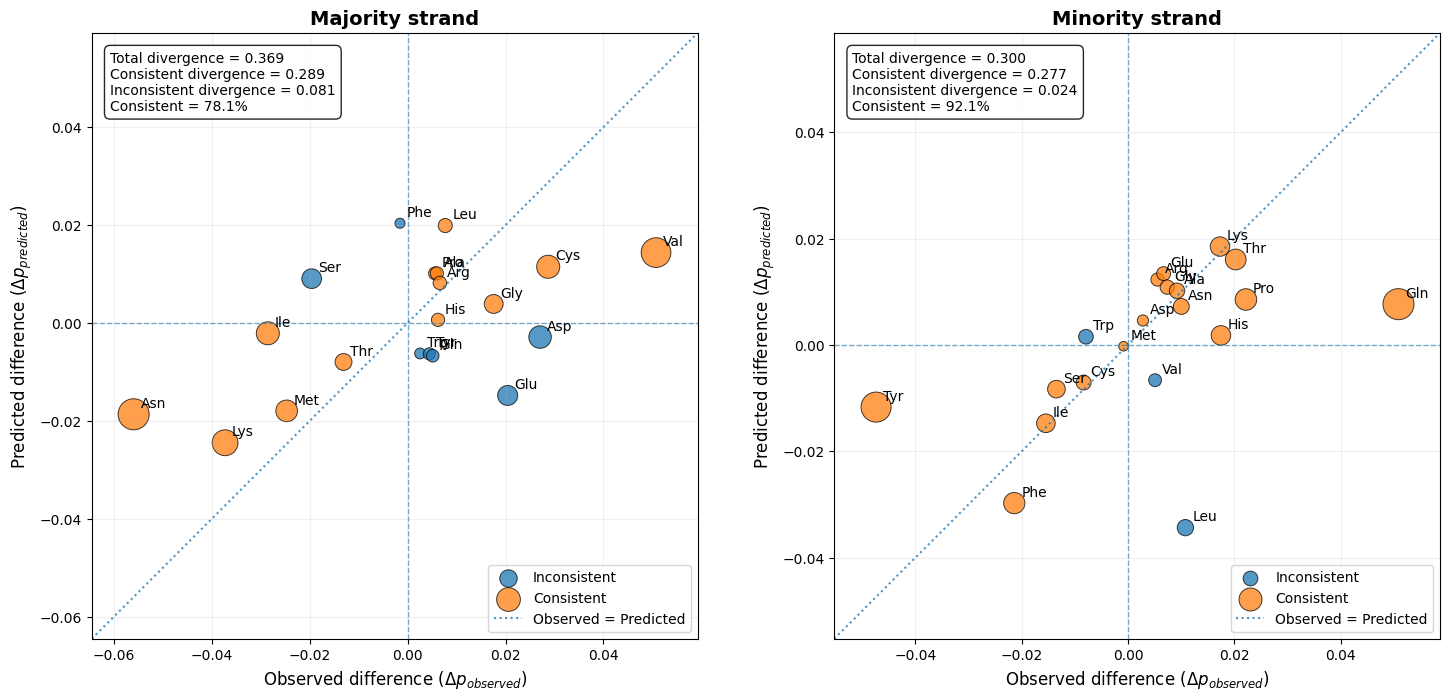

In [31]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 7)
)

ax1, majority_stats = plot_observed_vs_predicted(
    light_aa_summary,
    "Majority"
    ,
    ax=axes[0]
)

ax2, minority_stats = plot_observed_vs_predicted(
    heavy_aa_summary,
    "Minority",
    ax=axes[1]
)

plt.tight_layout()
plt.savefig('../figures/aa_consistent.pdf', dpi=300, bbox_inches = 'tight')
plt.show()